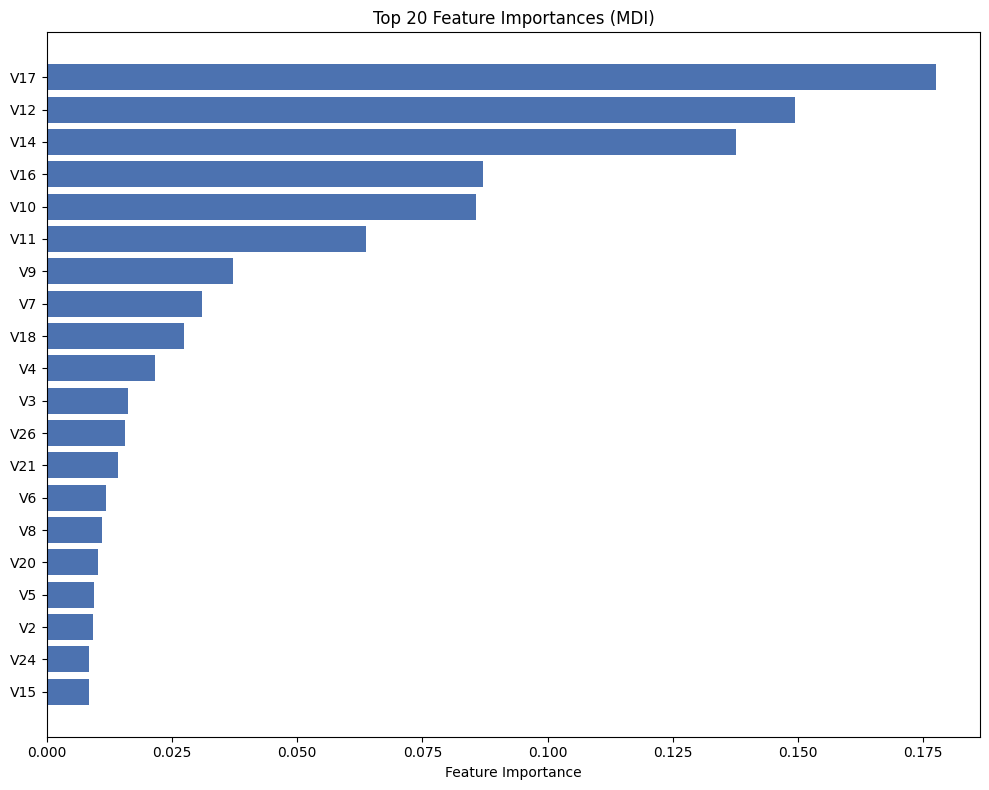

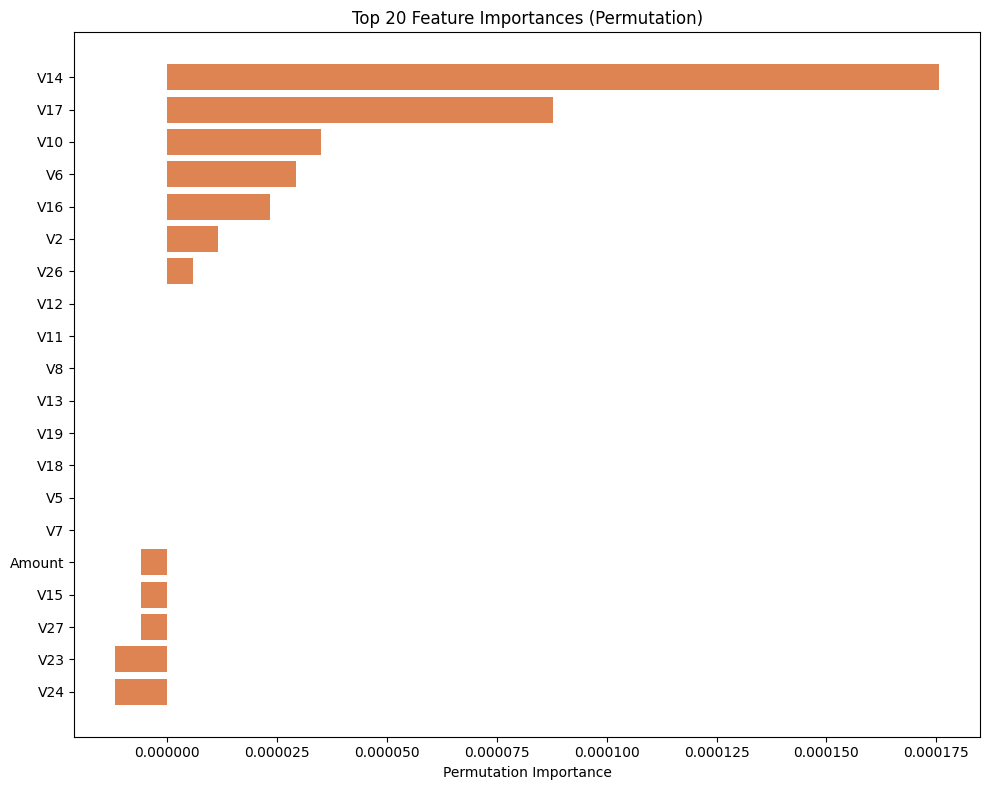

In [4]:
#  - Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance
import joblib
joblib.dump(model, "rf_model.pkl")
model = joblib.load("rf_model.pkl")

#  - Load data and model
X_train = pd.read_pickle("../../../../data/processed/X_train.pkl")
X_test  = pd.read_pickle("../../../../data/processed/X_test.pkl")
y_train = pd.read_pickle("../../../../data/processed/y_train.pkl")
y_test  = pd.read_pickle("../../../../data/processed/y_test.pkl")

# Load your trained model (adjust if you saved it differently)
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators=100, max_depth = 10,random_state=42)
model.fit(X_train, y_train)

#  Feature Importance (built-in)
feature_importance = model.feature_importances_
sorted_idx = np.argsort(feature_importance)[-20:]  # Top 20

plt.figure(figsize=(10, 8))
plt.barh(range(len(sorted_idx)), feature_importance[sorted_idx], color='#4C72B0')
plt.yticks(range(len(sorted_idx)), X_train.columns[sorted_idx])
plt.xlabel("Feature Importance")
plt.title("Top 20 Feature Importances (MDI)")
plt.tight_layout()
plt.show()

#  Permutation Importance (more reliable, like SHAP)
perm_imp = permutation_importance(
    model, X_test, y_test,
    n_repeats=3,   # instead of 10
    n_jobs=-1
)
sorted_idx = perm_imp.importances_mean.argsort()[-20:]

plt.figure(figsize=(10, 8))
plt.barh(range(len(sorted_idx)), perm_imp.importances_mean[sorted_idx], color='#DD8452')
plt.yticks(range(len(sorted_idx)), X_train.columns[sorted_idx])
plt.xlabel("Permutation Importance")
plt.title("Top 20 Feature Importances (Permutation)")
plt.tight_layout()
plt.show()
